# 02 — Data Preparation

## Traffic Accident Classification & Clustering

Tahap ini melakukan:

1. Pemilihan fitur
2. Decoding kode STATS19
3. Penanganan nilai khusus
4. Pemeriksaan data
5. Encoding fitur kategorikal
6. Persiapan data untuk Classification
7. Persiapan data untuk Clustering

Target klasifikasi:

`collision_severity`

Dataset:

DfT Road Safety Open Data — Collisions — Last 5 Years (2021–2025)

In [1]:
print("TEST KERNEL BERHASIL")

TEST KERNEL BERHASIL


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from IPython.display import display

print("Library berhasil di-load.")

Library berhasil di-load.


In [3]:
DATA_PATH = "../data/raw/dft-road-casualty-statistics-collision-last-5-years.csv"

df = pd.read_csv(DATA_PATH)

print(f"Jumlah baris: {len(df):,}")
print(f"Jumlah kolom: {df.shape[1]}")

C:\Users\Asyudi Anggara\AppData\Local\Temp\ipykernel_7872\2422920306.py:3: DtypeWarning: Columns (0: collision_index, 1: collision_ref_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Jumlah baris: 513,801
Jumlah kolom: 44


In [4]:
print("Daftar seluruh kolom:")
for i, col in enumerate(df.columns):
    print(f"{i:2}. {col}")

Daftar seluruh kolom:
 0. collision_index
 1. collision_year
 2. collision_ref_no
 3. location_easting_osgr
 4. location_northing_osgr
 5. longitude
 6. latitude
 7. police_force
 8. collision_severity
 9. number_of_vehicles
10. number_of_casualties
11. date
12. day_of_week
13. time
14. local_authority_district
15. local_authority_ons_district
16. local_authority_highway
17. local_authority_highway_current
18. first_road_class
19. first_road_number
20. road_type
21. speed_limit
22. junction_detail_historic
23. junction_detail
24. junction_control
25. second_road_class
26. second_road_number
27. pedestrian_crossing_human_control_historic
28. pedestrian_crossing_physical_facilities_historic
29. pedestrian_crossing
30. light_conditions
31. weather_conditions
32. road_surface_conditions
33. special_conditions_at_site
34. carriageway_hazards_historic
35. carriageway_hazards
36. urban_or_rural_area
37. did_police_officer_attend_scene_of_accident
38. trunk_road_flag
39. lsoa_of_accident_locat

In [5]:
candidate_features = [
    "number_of_vehicles",
    "day_of_week",
    "time",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "road_type",
    "first_road_class",
    "trunk_road_flag"
]

print("Fitur kandidat classification:")
for i, col in enumerate(candidate_features, start=1):
    print(f"{i:2}. {col}")

print(f"\nJumlah fitur kandidat: {len(candidate_features)}")

Fitur kandidat classification:
 1. number_of_vehicles
 2. day_of_week
 3. time
 4. speed_limit
 5. junction_detail
 6. junction_control
 7. light_conditions
 8. weather_conditions
 9. road_surface_conditions
10. urban_or_rural_area
11. road_type
12. first_road_class
13. trunk_road_flag

Jumlah fitur kandidat: 13


In [6]:
feature_check = pd.DataFrame({
    "feature": candidate_features,
    "dtype": [df[col].dtype for col in candidate_features],
    "missing": [df[col].isna().sum() for col in candidate_features],
    "unique": [df[col].nunique(dropna=False) for col in candidate_features]
})

display(feature_check)

,feature,dtype,missing,unique
0,number_of_vehicles,int64,0,19
1,day_of_week,int64,0,7
2,time,str,0,1440
3,speed_limit,int64,0,7
4,junction_detail,int64,0,8
5,junction_control,int64,0,6
6,light_conditions,int64,0,6
7,weather_conditions,int64,0,10
8,road_surface_conditions,int64,0,7
9,urban_or_rural_area,int64,0,4


In [7]:
# Cek distribusi nilai seluruh fitur kandidat

for col in candidate_features:
    print("=" * 60)
    print(f"FITUR: {col}")
    print(f"Jumlah nilai unik: {df[col].nunique()}")
    print(df[col].value_counts(dropna=False).sort_index())
    print()

FITUR: number_of_vehicles
Jumlah nilai unik: 19
number_of_vehicles
1     150641
2     317917
3      35016
4       7287
5       1917
6        604
7        244
8         80
9         31
10        28
11        13
12         8
13         5
14         1
15         1
16         3
17         3
20         1
26         1
Name: count, dtype: int64

FITUR: day_of_week
Jumlah nilai unik: 7
day_of_week
1    57781
2    70677
3    74829
4    76671
5    77954
6    85311
7    70578
Name: count, dtype: int64

FITUR: time
Jumlah nilai unik: 1440
time
00:00    144
00:01    661
00:02    134
00:03    126
00:04     90
        ... 
23:55    288
23:56     83
23:57     79
23:58    105
23:59    108
Name: count, Length: 1440, dtype: int64

FITUR: speed_limit
Jumlah nilai unik: 7
speed_limit
-1          3
 20     88096
 30    267325
 40     44750
 50     22666
 60     62703
 70     28258
Name: count, dtype: int64

FITUR: junction_detail
Jumlah nilai unik: 8
junction_detail
-1      19982
 0     252021
 13    142597

In [8]:
special_values = [-1, 9, 99]

special_summary = []

for col in candidate_features:
    for value in special_values:
        count = (df[col] == value).sum()
        
        if count > 0:
            special_summary.append({
                "feature": col,
                "special_value": value,
                "count": int(count),
                "percentage": round(count / len(df) * 100, 2)
            })

special_summary = pd.DataFrame(special_summary)

display(special_summary)

,feature,special_value,count,percentage
0,number_of_vehicles,9,31,0.01
1,speed_limit,-1,3,0.00
2,junction_detail,-1,19982,3.89
3,junction_detail,99,1429,0.28
4,junction_control,-1,217897,42.41
5,junction_control,9,11210,2.18
6,light_conditions,-1,34,0.01
7,weather_conditions,-1,12,0.00
8,weather_conditions,9,14566,2.83
9,road_surface_conditions,-1,3527,0.69


In [10]:
# ============================================
# CEK KOLOM KANDIDAT YANG TERSEDIA
# ============================================

candidate_features = [
    'speed_limit',
    'road_type',
    'first_road_class',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'number_of_vehicles',
    'day_of_week',
    'collision_severity'
]

# Cek mana yang tersedia dan mana yang tidak
available_features = [col for col in candidate_features if col in df.columns]
missing_features = [col for col in candidate_features if col not in df.columns]

print("Fitur yang tersedia:")
for col in available_features:
    print("✓", col)

print("\nFitur yang tidak ditemukan:")
for col in missing_features:
    print("✗", col)

print("\nJumlah fitur tersedia:", len(available_features))

Fitur yang tersedia:
✓ speed_limit
✓ road_type
✓ first_road_class
✓ junction_detail
✓ junction_control
✓ light_conditions
✓ weather_conditions
✓ road_surface_conditions
✓ urban_or_rural_area
✓ number_of_vehicles
✓ day_of_week
✓ collision_severity

Fitur yang tidak ditemukan:

Jumlah fitur tersedia: 12


In [11]:
# ============================================
# CEK DISTRIBUSI NILAI FITUR KANDIDAT
# ============================================

for col in available_features:
    print("\n" + "=" * 70)
    print(f"FITUR: {col}")
    print("=" * 70)

    print("Jumlah nilai unik:", df[col].nunique(dropna=False))

    print("\nDistribusi nilai:")
    print(df[col].value_counts(dropna=False).sort_index())


FITUR: speed_limit
Jumlah nilai unik: 7

Distribusi nilai:
speed_limit
-1          3
 20     88096
 30    267325
 40     44750
 50     22666
 60     62703
 70     28258
Name: count, dtype: int64

FITUR: road_type
Jumlah nilai unik: 6

Distribusi nilai:
road_type
1     31178
2     11550
3     76119
6    373065
7      8829
9     13060
Name: count, dtype: int64

FITUR: first_road_class
Jumlah nilai unik: 7

Distribusi nilai:
first_road_class
-1         6
 1     15452
 2      1239
 3    225830
 4     64452
 5     22612
 6    184210
Name: count, dtype: int64

FITUR: junction_detail
Jumlah nilai unik: 8

Distribusi nilai:
junction_detail
-1      19982
 0     252021
 13    142597
 16     47572
 17      7957
 18     11147
 19     31096
 99      1429
Name: count, dtype: int64

FITUR: junction_control
Jumlah nilai unik: 6

Distribusi nilai:
junction_control
-1    217897
 1      2210
 2     56431
 3      3484
 4    222569
 9     11210
Name: count, dtype: int64

FITUR: light_conditions
Jumlah nil

In [12]:
# ============================================
# DISTRIBUSI NILAI 12 FITUR KANDIDAT
# ============================================

for col in available_features:
    print("\n" + "=" * 70)
    print(f"FITUR: {col}")
    print("=" * 70)

    dist = df[col].value_counts(dropna=False).sort_index()

    print(f"Jumlah nilai unik : {df[col].nunique(dropna=False)}")
    print(f"Jumlah data       : {len(df):,}")

    print("\nDistribusi:")
    for value, count in dist.items():
        percentage = (count / len(df)) * 100
        print(f"{str(value):>10} : {count:>10,} ({percentage:>6.2f}%)")


FITUR: speed_limit
Jumlah nilai unik : 7
Jumlah data       : 513,801

Distribusi:
        -1 :          3 (  0.00%)
        20 :     88,096 ( 17.15%)
        30 :    267,325 ( 52.03%)
        40 :     44,750 (  8.71%)
        50 :     22,666 (  4.41%)
        60 :     62,703 ( 12.20%)
        70 :     28,258 (  5.50%)

FITUR: road_type
Jumlah nilai unik : 6
Jumlah data       : 513,801

Distribusi:
         1 :     31,178 (  6.07%)
         2 :     11,550 (  2.25%)
         3 :     76,119 ( 14.81%)
         6 :    373,065 ( 72.61%)
         7 :      8,829 (  1.72%)
         9 :     13,060 (  2.54%)

FITUR: first_road_class
Jumlah nilai unik : 7
Jumlah data       : 513,801

Distribusi:
        -1 :          6 (  0.00%)
         1 :     15,452 (  3.01%)
         2 :      1,239 (  0.24%)
         3 :    225,830 ( 43.95%)
         4 :     64,452 ( 12.54%)
         5 :     22,612 (  4.40%)
         6 :    184,210 ( 35.85%)

FITUR: junction_detail
Jumlah nilai unik : 8
Jumlah data       : 51

In [13]:
# ============================================
# TABEL DISTRIBUSI LENGKAP 12 FITUR
# ============================================

distribution_rows = []

for col in available_features:
    counts = df[col].value_counts(dropna=False).sort_index()

    for value, count in counts.items():
        percentage = (count / len(df)) * 100

        distribution_rows.append({
            "feature": col,
            "value": value,
            "count": count,
            "percentage": round(percentage, 2)
        })

distribution_df = pd.DataFrame(distribution_rows)

distribution_df

,feature,value,count,percentage
0,speed_limit,-1,3,0.00
1,speed_limit,20,88096,17.15
2,speed_limit,30,267325,52.03
3,speed_limit,40,44750,8.71
4,speed_limit,50,22666,4.41
...,...,...,...,...
85,day_of_week,6,85311,16.60
86,day_of_week,7,70578,13.74
87,collision_severity,1,7553,1.47
88,collision_severity,2,116813,22.74


In [14]:
# ============================================
# IDENTIFIKASI NILAI NEGATIF / KODE KHUSUS
# ============================================

special_code_df = distribution_df[
    distribution_df["value"].apply(
        lambda x: isinstance(x, (int, float)) and x < 0
    )
]

special_code_df

,feature,value,count,percentage
0,speed_limit,-1,3,0.00
13,first_road_class,-1,6,0.00
20,junction_detail,-1,19982,3.89
28,junction_control,-1,217897,42.41
34,light_conditions,-1,34,0.01
40,weather_conditions,-1,12,0.00
50,road_surface_conditions,-1,3527,0.69
57,urban_or_rural_area,-1,8,0.00


In [15]:
# ============================================
# RINGKASAN KODE SETIAP FITUR
# ============================================

for col in available_features:
    print(f"\n{col}")
    print("-" * 50)
    print(sorted(df[col].dropna().unique().tolist()))


speed_limit
--------------------------------------------------
[-1, 20, 30, 40, 50, 60, 70]

road_type
--------------------------------------------------
[1, 2, 3, 6, 7, 9]

first_road_class
--------------------------------------------------
[-1, 1, 2, 3, 4, 5, 6]

junction_detail
--------------------------------------------------
[-1, 0, 13, 16, 17, 18, 19, 99]

junction_control
--------------------------------------------------
[-1, 1, 2, 3, 4, 9]

light_conditions
--------------------------------------------------
[-1, 1, 4, 5, 6, 7]

weather_conditions
--------------------------------------------------
[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

road_surface_conditions
--------------------------------------------------
[-1, 1, 2, 3, 4, 5, 9]

urban_or_rural_area
--------------------------------------------------
[-1, 1, 2, 3]

number_of_vehicles
--------------------------------------------------
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 20, 26]

day_of_week
----------------

In [16]:
# ============================================
# RINGKASAN SELURUH KODE UNIK PER FITUR
# ============================================

code_summary = []

for col in available_features:
    codes = sorted(df[col].dropna().unique().tolist())

    code_summary.append({
        "feature": col,
        "jumlah_kode": len(codes),
        "kode": codes
    })

code_summary_df = pd.DataFrame(code_summary)

code_summary_df

,feature,jumlah_kode,kode
0,speed_limit,7,"[-1, 20, 30, 40, 50, 60, 70]"
1,road_type,6,"[1, 2, 3, 6, 7, 9]"
2,first_road_class,7,"[-1, 1, 2, 3, 4, 5, 6]"
3,junction_detail,8,"[-1, 0, 13, 16, 17, 18, 19, 99]"
4,junction_control,6,"[-1, 1, 2, 3, 4, 9]"
5,light_conditions,6,"[-1, 1, 4, 5, 6, 7]"
6,weather_conditions,10,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
7,road_surface_conditions,7,"[-1, 1, 2, 3, 4, 5, 9]"
8,urban_or_rural_area,4,"[-1, 1, 2, 3]"
9,number_of_vehicles,19,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [17]:
# ============================================
# DECODING STATS19
# ============================================

# Mapping kode STATS19
stats19_maps = {

    "collision_severity": {
        1: "Fatal",
        2: "Serious",
        3: "Slight"
    },

    "first_road_class": {
        -1: "Data missing / out of range",
        1: "Motorway",
        2: "A(M)",
        3: "A",
        4: "B",
        5: "C",
        6: "Unclassified"
    },

    "road_type": {
        -1: "Data missing / out of range",
        1: "Roundabout",
        2: "One way street",
        3: "Dual carriageway",
        6: "Single carriageway",
        7: "Slip road",
        9: "Unknown"
    },

    "junction_detail": {
        -1: "Data missing / out of range",
        0: "Not at or within 20 metres of junction",
        13: "T or staggered junction",
        16: "Crossroads",
        17: "Junction with more than four arms",
        18: "Using private drive or entrance",
        19: "Other junction",
        99: "Unknown"
    },

    "junction_control": {
        -1: "Data missing / out of range",
        1: "Authorised person",
        2: "Automatic traffic signal",
        3: "Stop sign",
        4: "Give way or uncontrolled",
        9: "Unknown"
    },

    "light_conditions": {
        -1: "Data missing / out of range",
        1: "Daylight",
        4: "Darkness - lights lit",
        5: "Darkness - lights unlit",
        6: "Darkness - no lighting",
        7: "Darkness - lighting unknown"
    },

    "weather_conditions": {
        -1: "Data missing / out of range",
        1: "Fine no high winds",
        2: "Raining no high winds",
        3: "Snowing no high winds",
        4: "Fine + high winds",
        5: "Raining + high winds",
        6: "Snowing + high winds",
        7: "Fog or mist",
        8: "Other",
        9: "Unknown"
    },

    "road_surface_conditions": {
        -1: "Data missing / out of range",
        1: "Dry",
        2: "Wet or damp",
        3: "Snow",
        4: "Frost or ice",
        5: "Flood over 3cm deep",
        6: "Oil or diesel",
        7: "Mud",
        9: "Unknown"
    },

    "urban_or_rural_area": {
        -1: "Data missing / out of range",
        1: "Urban",
        2: "Rural",
        3: "Unallocated"
    },

    "day_of_week": {
        1: "Sunday",
        2: "Monday",
        3: "Tuesday",
        4: "Wednesday",
        5: "Thursday",
        6: "Friday",
        7: "Saturday"
    }
}

print("Mapping STATS19 berhasil dibuat.")
print("Jumlah fitur yang memiliki mapping:", len(stats19_maps))

Mapping STATS19 berhasil dibuat.
Jumlah fitur yang memiliki mapping: 10


In [18]:
# ============================================
# VALIDASI MAPPING TERHADAP KODE DATASET
# ============================================

mapping_check = []

for col, mapping in stats19_maps.items():

    actual_codes = set(df[col].dropna().unique())
    mapped_codes = set(mapping.keys())

    unmapped = sorted(actual_codes - mapped_codes)

    mapping_check.append({
        "feature": col,
        "kode_dataset": sorted(actual_codes),
        "kode_mapping": sorted(mapped_codes),
        "unmapped": unmapped,
        "status": "OK" if len(unmapped) == 0 else "PERLU CEK"
    })

mapping_check_df = pd.DataFrame(mapping_check)

mapping_check_df

,feature,kode_dataset,kode_mapping,unmapped,status
0,collision_severity,"[1, 2, 3]","[1, 2, 3]",[],OK
1,first_road_class,"[-1, 1, 2, 3, 4, 5, 6]","[-1, 1, 2, 3, 4, 5, 6]",[],OK
2,road_type,"[1, 2, 3, 6, 7, 9]","[-1, 1, 2, 3, 6, 7, 9]",[],OK
3,junction_detail,"[-1, 0, 13, 16, 17, 18, 19, 99]","[-1, 0, 13, 16, 17, 18, 19, 99]",[],OK
4,junction_control,"[-1, 1, 2, 3, 4, 9]","[-1, 1, 2, 3, 4, 9]",[],OK
5,light_conditions,"[-1, 1, 4, 5, 6, 7]","[-1, 1, 4, 5, 6, 7]",[],OK
6,weather_conditions,"[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]",[],OK
7,road_surface_conditions,"[-1, 1, 2, 3, 4, 5, 9]","[-1, 1, 2, 3, 4, 5, 6, 7, 9]",[],OK
8,urban_or_rural_area,"[-1, 1, 2, 3]","[-1, 1, 2, 3]",[],OK
9,day_of_week,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",[],OK


In [19]:
# ============================================
# BUAT DATAFRAME HASIL DECODING
# ============================================

df_decoded = df.copy()

for col, mapping in stats19_maps.items():
    df_decoded[col] = df_decoded[col].map(mapping)

print("Decoding selesai.")
print("Shape:", df_decoded.shape)

df_decoded[available_features].head()

Decoding selesai.
Shape: (513801, 44)


,speed_limit,road_type,first_road_class,junction_detail,junction_control,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area,number_of_vehicles,day_of_week,collision_severity
0,30,Single carriageway,Unclassified,Crossroads,Give way or uncontrolled,Darkness - lights lit,Fine no high winds,Dry,Urban,1,Saturday,Slight
1,30,Single carriageway,A,Not at or within 20 metres of junction,Data missing / out of range,Daylight,Fine no high winds,Dry,Urban,1,Tuesday,Serious
2,30,Single carriageway,Unclassified,T or staggered junction,Give way or uncontrolled,Darkness - lights lit,Raining no high winds,Wet or damp,Urban,2,Friday,Slight
3,30,Single carriageway,B,Not at or within 20 metres of junction,Data missing / out of range,Daylight,Fine no high winds,Dry,Urban,1,Tuesday,Fatal
4,30,Single carriageway,B,Crossroads,Give way or uncontrolled,Daylight,Fine no high winds,Dry,Urban,2,Monday,Slight


In [58]:
# ============================================
# SIMPAN MAPPING STATS19
# ============================================

import json
from pathlib import Path

MAPPING_PATH = Path("../data/processed/stats19_maps.json")
MAPPING_PATH.parent.mkdir(parents=True, exist_ok=True)

stats19_maps_json = {
    str(col): {
        str(code): str(label)
        for code, label in mapping.items()
    }
    for col, mapping in stats19_maps.items()
}

with open(MAPPING_PATH, "w", encoding="utf-8") as f:
    json.dump(
        stats19_maps_json,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Mapping berhasil disimpan.")
print(MAPPING_PATH.resolve())

Mapping berhasil disimpan.
D:\Dev\Projects\traffic-accident-ml\data\processed\stats19_maps.json


In [20]:
# ============================================
# FINAL FEATURE SELECTION
# ============================================

feature_columns = [
    'speed_limit',
    'road_type',
    'first_road_class',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'number_of_vehicles',
    'day_of_week'
]

target_column = 'collision_severity'

# Dataset final untuk classification
df_model = df_decoded[feature_columns + [target_column]].copy()

print("Shape dataset model:", df_model.shape)

print("\nFitur predictor:")
for i, col in enumerate(feature_columns, start=1):
    print(f"{i:2}. {col}")

print("\nTarget:")
print(f"   {target_column}")

Shape dataset model: (513801, 12)

Fitur predictor:
 1. speed_limit
 2. road_type
 3. first_road_class
 4. junction_detail
 5. junction_control
 6. light_conditions
 7. weather_conditions
 8. road_surface_conditions
 9. urban_or_rural_area
10. number_of_vehicles
11. day_of_week

Target:
   collision_severity


In [21]:
# ============================================
# QUALITY CHECK DATASET FINAL
# ============================================

quality_check = pd.DataFrame({
    'dtype': df_model.dtypes,
    'missing': df_model.isna().sum(),
    'unique': df_model.nunique(dropna=False)
})

quality_check

,dtype,missing,unique
speed_limit,int64,0,7
road_type,str,0,6
first_road_class,str,0,7
junction_detail,str,0,8
junction_control,str,0,6
light_conditions,str,0,6
weather_conditions,str,0,10
road_surface_conditions,str,0,7
urban_or_rural_area,str,0,4
number_of_vehicles,int64,0,19


In [22]:
# ============================================
# CEK FITUR NUMERIK
# ============================================

print("SPEED LIMIT")
print(df_model['speed_limit'].describe())

print("\nNUMBER OF VEHICLES")
print(df_model['number_of_vehicles'].describe())

SPEED LIMIT
count    513801.000000
mean         35.899516
std          14.371273
min          -1.000000
25%          30.000000
50%          30.000000
75%          40.000000
max          70.000000
Name: speed_limit, dtype: float64

NUMBER OF VEHICLES
count    513801.000000
mean          1.824179
std           0.687802
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max          26.000000
Name: number_of_vehicles, dtype: float64


In [23]:
# ============================================
# PEMISAHAN FITUR NUMERIK & KATEGORIKAL
# ============================================

numeric_features = [
    'speed_limit',
    'number_of_vehicles'
]

categorical_features = [
    'road_type',
    'first_road_class',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'day_of_week'
]

print("Fitur numerik:")
for col in numeric_features:
    print(" -", col)

print("\nFitur kategorikal:")
for col in categorical_features:
    print(" -", col)

print("\nTotal fitur:", len(numeric_features) + len(categorical_features))

Fitur numerik:
 - speed_limit
 - number_of_vehicles

Fitur kategorikal:
 - road_type
 - first_road_class
 - junction_detail
 - junction_control
 - light_conditions
 - weather_conditions
 - road_surface_conditions
 - urban_or_rural_area
 - day_of_week

Total fitur: 11


In [24]:
# ============================================
# CEK KOLOM TAHUN
# ============================================

[col for col in df_decoded.columns if 'year' in col.lower()]

['collision_year']

In [26]:
# ============================================
# SAMPLE 10.000
# 2.000 RECORD PER TAHUN
# ============================================

year_column = 'collision_year'

df_sample = (
    df_decoded
    .groupby(year_column, group_keys=False)
    .sample(n=2000, random_state=42)
)

df_sample_model = df_sample[feature_columns + [target_column]].copy()

print("Shape sample:", df_sample_model.shape)

print("\nDistribusi tahun:")
print(df_sample[year_column].value_counts().sort_index())

Shape sample: (10000, 12)

Distribusi tahun:
collision_year
2021    2000
2022    2000
2023    2000
2024    2000
2025    2000
Name: count, dtype: int64


In [27]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X = df_sample_model[feature_columns]
y = df_sample_model[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribusi target TRAIN:")
print(
    y_train
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percentage=lambda x: (x["count"] / len(y_train) * 100).round(2)
    )
)

print("\nDistribusi target TEST:")
print(
    y_test
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(
        percentage=lambda x: (x["count"] / len(y_test) * 100).round(2)
    )
)

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)

Distribusi target TRAIN:
                    count  percentage
collision_severity                   
Fatal                 111        1.39
Serious              1813       22.66
Slight               6076       75.95

Distribusi target TEST:
                    count  percentage
collision_severity                   
Fatal                  28        1.40
Serious               453       22.65
Slight               1519       75.95


In [28]:
# ============================================
# ENCODING + SCALING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train encoded:", X_train_encoded.shape)
print("X_test encoded :", X_test_encoded.shape)

X_train encoded: (8000, 59)
X_test encoded : (2000, 59)


In [29]:
# ============================================
# CLASSIFICATION - BASELINE & MODEL
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# 1. BASELINE
# --------------------------------------------

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train_encoded, y_train)

dummy_pred = dummy_model.predict(X_test_encoded)


# --------------------------------------------
# 2. LOGISTIC REGRESSION
# --------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_encoded,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_encoded
)


# --------------------------------------------
# 3. DECISION TREE
# --------------------------------------------

tree_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(
    X_train_encoded,
    y_train
)

tree_pred = tree_model.predict(
    X_test_encoded
)


# --------------------------------------------
# 4. RANDOM FOREST
# --------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

rf_pred = rf_model.predict(
    X_test_encoded
)

print("Semua model berhasil dilatih.")

Semua model berhasil dilatih.


In [30]:
# ============================================
# EVALUASI CLASSIFICATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

models = {
    "Baseline": dummy_pred,
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

results = []

for name, pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision Macro": precision_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Macro",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest,0.5890,0.358372,0.389741,0.358455
1,Decision Tree,0.4665,0.354777,0.425005,0.318633
2,Logistic Regression,0.4370,0.360350,0.479587,0.312156
3,Baseline,0.7595,0.253167,0.333333,0.287771


Model terbaik sementara: Random Forest


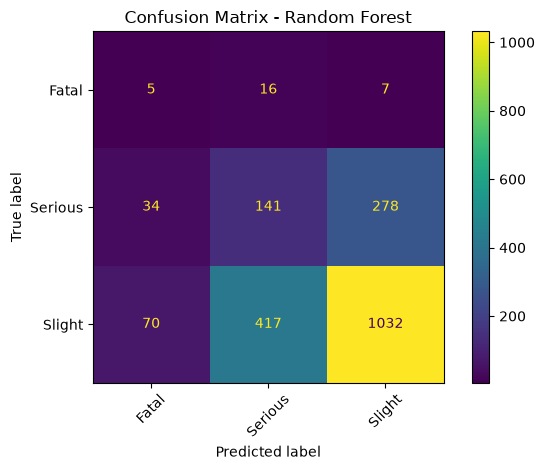

In [31]:
# ============================================
# CONFUSION MATRIX
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = results_df.iloc[0]["Model"]

predictions = {
    "Baseline": dummy_pred,
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

best_pred = predictions[best_model_name]

print("Model terbaik sementara:", best_model_name)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    labels=["Fatal", "Serious", "Slight"],
    xticks_rotation=45
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_pred,
        labels=["Fatal", "Serious", "Slight"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Fatal       0.05      0.18      0.07        28
     Serious       0.25      0.31      0.27       453
      Slight       0.78      0.68      0.73      1519

    accuracy                           0.59      2000
   macro avg       0.36      0.39      0.36      2000
weighted avg       0.65      0.59      0.62      2000



In [33]:
# ============================================
# CLASSIFICATION IMPROVEMENT
# TAMBAHAN MODEL
# ============================================

from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier

# --------------------------------------------
# 1. LINEAR SVM
# --------------------------------------------

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_encoded,
    y_train
)

svm_pred = svm_model.predict(
    X_test_encoded
)


# --------------------------------------------
# 2. EXTRA TREES
# --------------------------------------------

extra_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

extra_model.fit(
    X_train_encoded,
    y_train
)

extra_pred = extra_model.predict(
    X_test_encoded
)

print("Model tambahan berhasil dilatih.")

Model tambahan berhasil dilatih.


In [34]:
# ============================================
# PERBANDINGAN SEMUA MODEL
# ============================================

all_models = {
    "Baseline": dummy_pred,
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "Linear SVM": svm_pred,
    "Extra Trees": extra_pred
}

all_results = []

for name, pred in all_models.items():

    all_results.append({
        "Model": name,
        "Accuracy": round(
            accuracy_score(y_test, pred), 4
        ),
        "Precision Macro": round(
            precision_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            ), 4
        ),
        "Recall Macro": round(
            recall_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            ), 4
        ),
        "F1 Macro": round(
            f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            ), 4
        )
    })

all_results_df = (
    pd.DataFrame(all_results)
    .sort_values(
        "F1 Macro",
        ascending=False
    )
    .reset_index(drop=True)
)

all_results_df

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest,0.5890,0.3584,0.3897,0.3585
1,Extra Trees,0.6015,0.3481,0.3772,0.3469
2,Linear SVM,0.7055,0.3958,0.4545,0.3317
3,Decision Tree,0.4665,0.3548,0.4250,0.3186
4,Logistic Regression,0.4370,0.3603,0.4796,0.3122
5,Baseline,0.7595,0.2532,0.3333,0.2878


In [35]:
# ============================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ============================================

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance
0,num__speed_limit,0.117040
1,num__number_of_vehicles,0.101381
2,cat__light_conditions_Daylight,0.031547
3,cat__first_road_class_A,0.030900
4,cat__day_of_week_Monday,0.030491
5,cat__first_road_class_Unclassified,0.029491
6,cat__day_of_week_Friday,0.028583
7,cat__day_of_week_Thursday,0.028272
8,cat__day_of_week_Saturday,0.027697
9,cat__road_surface_conditions_Wet or damp,0.026177


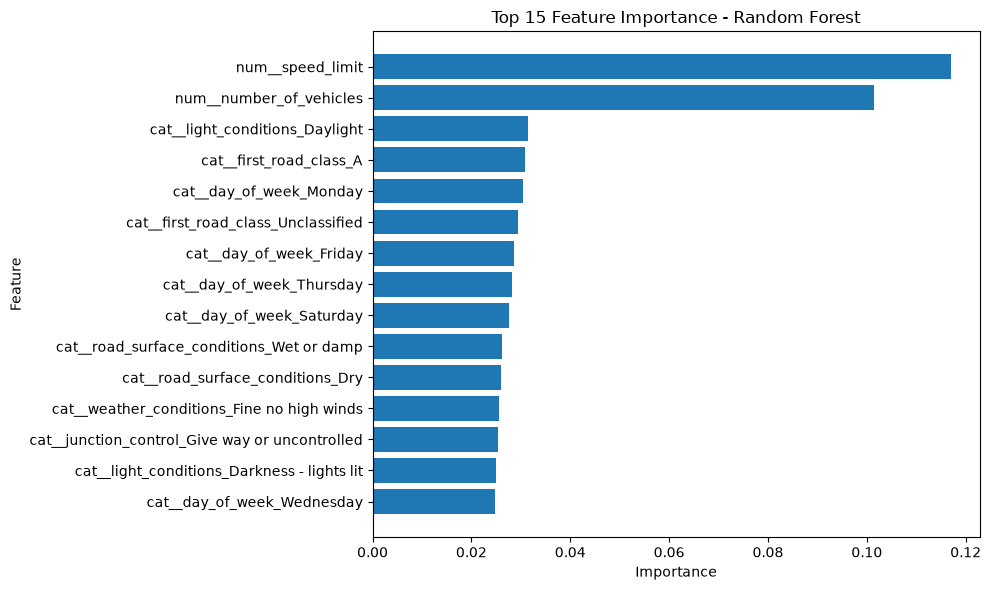

In [36]:
# ============================================
# TOP 15 FEATURE IMPORTANCE
# ============================================

import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

In [37]:
# ============================================
# CLUSTERING - DATASET
# ============================================

cluster_features = [
    'speed_limit',
    'road_type',
    'first_road_class',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'number_of_vehicles',
    'day_of_week'
]

# Gunakan sample 10.000 yang sama
df_cluster = df_sample_model[cluster_features].copy()

print("Shape clustering:", df_cluster.shape)
print("\nFitur clustering:")
for i, col in enumerate(cluster_features, start=1):
    print(f"{i}. {col}")

Shape clustering: (10000, 11)

Fitur clustering:
1. speed_limit
2. road_type
3. first_road_class
4. junction_detail
5. junction_control
6. light_conditions
7. weather_conditions
8. road_surface_conditions
9. urban_or_rural_area
10. number_of_vehicles
11. day_of_week


In [38]:
# ============================================
# CLUSTERING - PREPROCESSING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cluster_numeric = [
    'speed_limit',
    'number_of_vehicles'
]

cluster_categorical = [
    'road_type',
    'first_road_class',
    'junction_detail',
    'junction_control',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'urban_or_rural_area',
    'day_of_week'
]

cluster_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            cluster_numeric
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            ),
            cluster_categorical
        )
    ]
)

X_cluster_encoded = cluster_preprocessor.fit_transform(df_cluster)

print("Shape sebelum encoding:", df_cluster.shape)
print("Shape setelah encoding:", X_cluster_encoded.shape)

Shape sebelum encoding: (10000, 11)
Shape setelah encoding: (10000, 60)


In [39]:
# ============================================
# MENENTUKAN JUMLAH CLUSTER
# ELBOW + SILHOUETTE
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_encoded)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(
        X_cluster_encoded,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K={k} | "
        f"Inertia={kmeans.inertia_:.2f} | "
        f"Silhouette={score:.4f}"
    )

K=2 | Inertia=57022.45 | Silhouette=0.2034
K=3 | Inertia=52480.14 | Silhouette=0.1208
K=4 | Inertia=49724.97 | Silhouette=0.1174
K=5 | Inertia=47929.03 | Silhouette=0.1152
K=6 | Inertia=45491.81 | Silhouette=0.1107
K=7 | Inertia=44197.13 | Silhouette=0.1066
K=8 | Inertia=42812.68 | Silhouette=0.1083


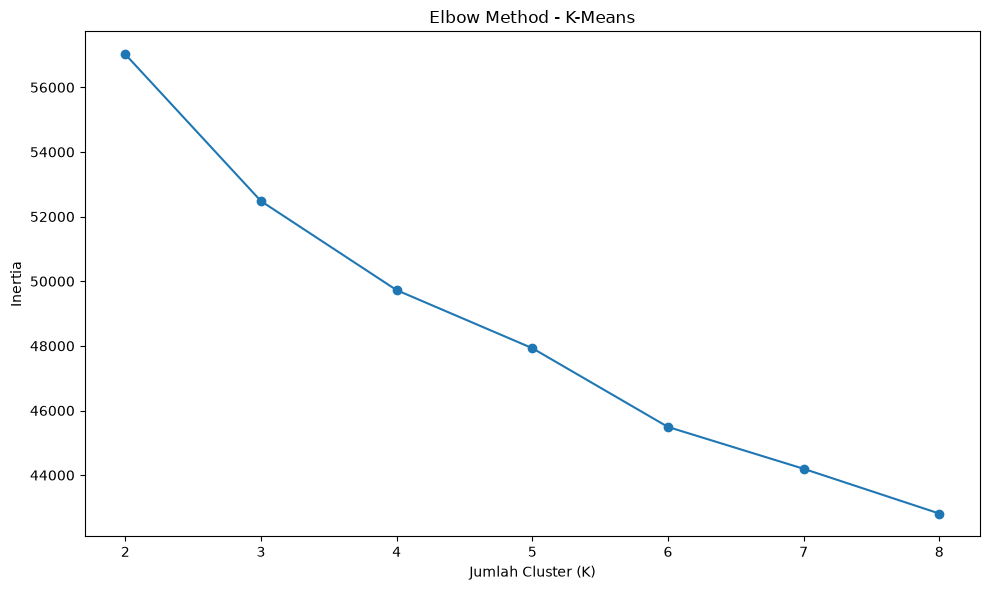

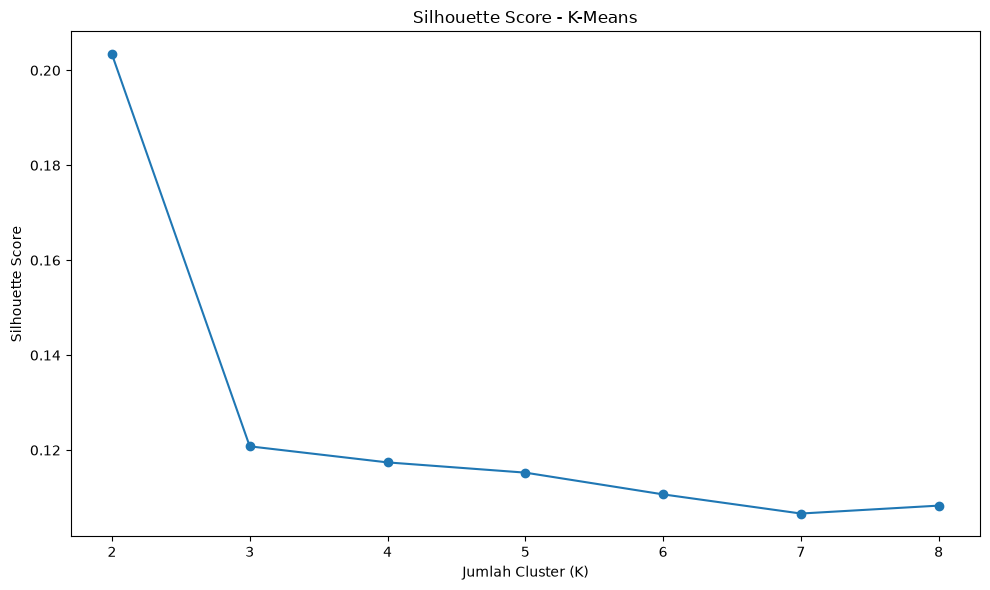

In [40]:
# ============================================
# ELBOW METHOD & SILHOUETTE SCORE
# ============================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Elbow
ax1.plot(
    list(k_values),
    inertias,
    marker='o'
)

ax1.set_xlabel("Jumlah Cluster (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method - K-Means")
ax1.set_xticks(list(k_values))

plt.tight_layout()
plt.show()


# Silhouette Score
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - K-Means")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [41]:
# ============================================
# K-MEANS FINAL
# ============================================

from sklearn.cluster import KMeans

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster_encoded)

print("K-Means final berhasil.")
print("Jumlah cluster:", final_k)
print("Jumlah data:", len(cluster_labels))

K-Means final berhasil.
Jumlah cluster: 2
Jumlah data: 10000


In [42]:
# ============================================
# MENAMBAHKAN LABEL CLUSTER
# ============================================

df_cluster_result = df_cluster.copy()

df_cluster_result["cluster"] = cluster_labels

print("Shape:", df_cluster_result.shape)

print("\nDistribusi cluster:")
print(
    df_cluster_result["cluster"]
    .value_counts()
    .sort_index()
)

Shape: (10000, 12)

Distribusi cluster:
cluster
0    2486
1    7514
Name: count, dtype: int64


In [43]:
# ============================================
# PROFIL CLUSTER - FITUR NUMERIK
# ============================================

cluster_numeric_profile = (
    df_cluster_result
    .groupby("cluster")[cluster_numeric]
    .agg(["count", "mean", "median", "min", "max"])
)

cluster_numeric_profile

speed_limit                           number_of_vehicles           \
              count       mean median min max              count     mean   
cluster                                                                     
0              2486  58.125503   60.0  30  70               2486  1.91794   
1              7514  28.529412   30.0  20  50               7514  1.78946   

                        
        median min max  
cluster                 
0          2.0   1  16  
1          2.0   1   8

In [44]:
# ============================================
# PROFIL CLUSTER - FITUR KATEGORIKAL
# ============================================

for feature in cluster_categorical:
    print("\n" + "=" * 60)
    print(f"FITUR: {feature}")
    print("=" * 60)

    profile = pd.crosstab(
        df_cluster_result["cluster"],
        df_cluster_result[feature],
        normalize="index"
    ) * 100

    print(profile.round(2))


FITUR: road_type
road_type  Dual carriageway  One way street  Roundabout  Single carriageway  \
cluster                                                                       
0                     27.92            0.04        5.55               63.03   
1                     10.31            3.27        6.57               75.35   

road_type  Slip road  Unknown  
cluster                        
0               2.94     0.52  
1               1.26     3.22  

FITUR: first_road_class
first_road_class      A  A(M)      B     C  Motorway  Unclassified
cluster                                                           
0                 53.78  0.72  12.67  2.90     11.06         18.87
1                 41.11  0.00  12.36  4.71      0.17         41.64

FITUR: junction_detail
junction_detail  Crossroads  Data missing / out of range  \
cluster                                                    
0                      3.54                         2.09   
1                     10.87             

In [45]:
# ============================================
# RINGKASAN KATEGORI DOMINAN PER CLUSTER
# ============================================

cluster_category_summary = []

for feature in cluster_categorical:
    profile = pd.crosstab(
        df_cluster_result["cluster"],
        df_cluster_result[feature],
        normalize="index"
    ) * 100

    for cluster_id in profile.index:
        top_category = profile.loc[cluster_id].idxmax()
        top_percentage = profile.loc[cluster_id].max()

        cluster_category_summary.append({
            "cluster": cluster_id,
            "feature": feature,
            "kategori_dominan": top_category,
            "persentase": round(top_percentage, 2)
        })

cluster_category_summary_df = pd.DataFrame(
    cluster_category_summary
)

cluster_category_summary_df

,cluster,feature,kategori_dominan,persentase
0,0,road_type,Single carriageway,63.03
1,1,road_type,Single carriageway,75.35
2,0,first_road_class,A,53.78
3,1,first_road_class,Unclassified,41.64
4,0,junction_detail,Not at or within 20 metres of junction,76.67
5,1,junction_detail,Not at or within 20 metres of junction,40.83
6,0,junction_control,Data missing / out of range,70.23
7,1,junction_control,Give way or uncontrolled,48.20
8,0,light_conditions,Daylight,72.77
9,1,light_conditions,Daylight,71.80


In [46]:
# ============================================
# HUBUNGAN CLUSTER DENGAN COLLISION SEVERITY
# ============================================

cluster_severity_profile = (
    pd.crosstab(
        df_cluster_result["cluster"],
        df_cluster_result["collision_severity"],
        normalize="index"
    ) * 100
)

cluster_severity_profile.round(2)

KeyError: 'collision_severity'

In [47]:
# ============================================
# HUBUNGAN CLUSTER DENGAN COLLISION SEVERITY
# ============================================

# Ambil collision_severity dari dataset asal
# berdasarkan index yang sama dengan df_cluster_result

df_cluster_result["collision_severity"] = (
    df_model.loc[df_cluster_result.index, "collision_severity"]
)

print("Kolom berhasil ditambahkan.")
print(
    df_cluster_result[
        ["cluster", "collision_severity"]
    ].head()
)

Kolom berhasil ditambahkan.
        cluster collision_severity
194696        1             Slight
266493        1             Slight
503795        1             Slight
169180        1             Slight
352066        1             Slight


In [48]:
# ============================================
# PROFIL CLUSTER BERDASARKAN SEVERITY
# ============================================

cluster_severity_profile = (
    pd.crosstab(
        df_cluster_result["cluster"],
        df_cluster_result["collision_severity"],
        normalize="index"
    ) * 100
)

cluster_severity_profile.round(2)

collision_severity,Fatal,Serious,Slight
cluster,,,
0,2.98,27.31,69.71
1,0.87,21.12,78.01


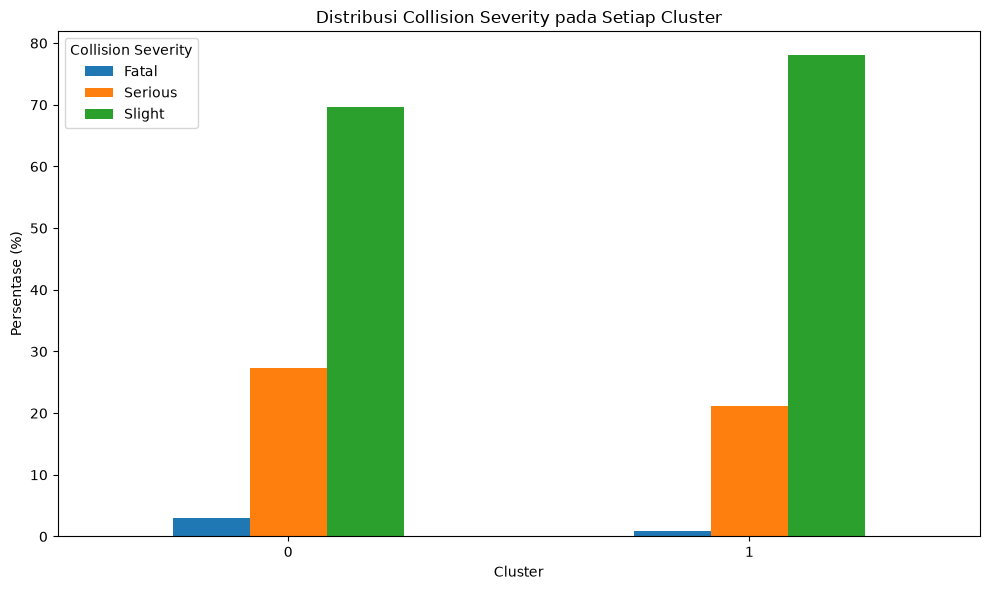

In [49]:
# ============================================
# VISUALISASI CLUSTER × COLLISION SEVERITY
# ============================================

import matplotlib.pyplot as plt

ax = cluster_severity_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Persentase (%)")
plt.title("Distribusi Collision Severity pada Setiap Cluster")
plt.xticks(rotation=0)
plt.legend(title="Collision Severity")
plt.tight_layout()
plt.show()

In [50]:
# ============================================
# RINGKASAN PROFIL CLUSTER
# ============================================

cluster_summary = pd.DataFrame({
    "Jumlah Data": df_cluster_result["cluster"].value_counts().sort_index(),
    "Rata-rata Speed Limit": (
        df_cluster_result.groupby("cluster")["speed_limit"].mean()
    ),
    "Median Speed Limit": (
        df_cluster_result.groupby("cluster")["speed_limit"].median()
    ),
    "Rata-rata Jumlah Kendaraan": (
        df_cluster_result.groupby("cluster")["number_of_vehicles"].mean()
    ),
    "Median Jumlah Kendaraan": (
        df_cluster_result.groupby("cluster")["number_of_vehicles"].median()
    ),
    "Fatal (%)": cluster_severity_profile["Fatal"],
    "Serious (%)": cluster_severity_profile["Serious"],
    "Slight (%)": cluster_severity_profile["Slight"]
})

cluster_summary.round(2)

,Jumlah Data,Rata-rata Speed Limit,Median Speed Limit,Rata-rata Jumlah Kendaraan,Median Jumlah Kendaraan,Fatal (%),Serious (%),Slight (%)
cluster,,,,,,,,
0,2486,58.13,60.0,1.92,2.0,2.98,27.31,69.71
1,7514,28.53,30.0,1.79,2.0,0.87,21.12,78.01


In [51]:
# ============================================
# PROFIL UTAMA SETIAP CLUSTER
# ============================================

profile_final = pd.DataFrame({
    "Cluster 0": {
        "Jumlah Data": cluster_summary.loc[0, "Jumlah Data"],
        "Rata-rata Speed Limit": cluster_summary.loc[0, "Rata-rata Speed Limit"],
        "Rata-rata Kendaraan": cluster_summary.loc[0, "Rata-rata Jumlah Kendaraan"],
        "Fatal (%)": cluster_summary.loc[0, "Fatal (%)"],
        "Serious (%)": cluster_summary.loc[0, "Serious (%)"],
        "Slight (%)": cluster_summary.loc[0, "Slight (%)"],
    },
    
    "Cluster 1": {
        "Jumlah Data": cluster_summary.loc[1, "Jumlah Data"],
        "Rata-rata Speed Limit": cluster_summary.loc[1, "Rata-rata Speed Limit"],
        "Rata-rata Kendaraan": cluster_summary.loc[1, "Rata-rata Jumlah Kendaraan"],
        "Fatal (%)": cluster_summary.loc[1, "Fatal (%)"],
        "Serious (%)": cluster_summary.loc[1, "Serious (%)"],
        "Slight (%)": cluster_summary.loc[1, "Slight (%)"],
    }
})

profile_final.round(2)

,Cluster 0,Cluster 1
Jumlah Data,2486.00,7514.00
Rata-rata Speed Limit,58.13,28.53
Rata-rata Kendaraan,1.92,1.79
Fatal (%),2.98,0.87
Serious (%),27.31,21.12
Slight (%),69.71,78.01


In [52]:
# ============================================
# PROFIL KATEGORIKAL UTAMA SETIAP CLUSTER
# ============================================

categorical_profile_final = []

important_features = [
    "road_type",
    "first_road_class",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "day_of_week"
]

for feature in important_features:
    for cluster_id in sorted(df_cluster_result["cluster"].unique()):
        
        profile = pd.crosstab(
            df_cluster_result["cluster"],
            df_cluster_result[feature],
            normalize="index"
        ) * 100
        
        dominant_category = profile.loc[cluster_id].idxmax()
        dominant_percentage = profile.loc[cluster_id].max()
        
        categorical_profile_final.append({
            "Cluster": cluster_id,
            "Fitur": feature,
            "Kategori Dominan": dominant_category,
            "Persentase (%)": round(dominant_percentage, 2)
        })

categorical_profile_final = pd.DataFrame(
    categorical_profile_final
)

categorical_profile_final

,Cluster,Fitur,Kategori Dominan,Persentase (%)
0,0,road_type,Single carriageway,63.03
1,1,road_type,Single carriageway,75.35
2,0,first_road_class,A,53.78
3,1,first_road_class,Unclassified,41.64
4,0,junction_detail,Not at or within 20 metres of junction,76.67
5,1,junction_detail,Not at or within 20 metres of junction,40.83
6,0,junction_control,Data missing / out of range,70.23
7,1,junction_control,Give way or uncontrolled,48.20
8,0,light_conditions,Daylight,72.77
9,1,light_conditions,Daylight,71.80


In [53]:
# ============================================
# PCA 2D - VISUALISASI HASIL CLUSTERING
# ============================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster_encoded)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

print("Shape PCA:", X_pca.shape)

print("\nExplained Variance Ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))

print(
    "\nTotal Explained Variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

pca_df.head()

Shape PCA: (10000, 2)

Explained Variance Ratio:
PC1: 0.2103
PC2: 0.1456

Total Explained Variance: 0.3559


,PC1,PC2,cluster
0,-0.279725,0.141190,1
1,-0.016670,0.076093,1
2,-0.536779,0.293414,1
3,0.413211,0.037360,1
4,-0.657799,1.901922,1


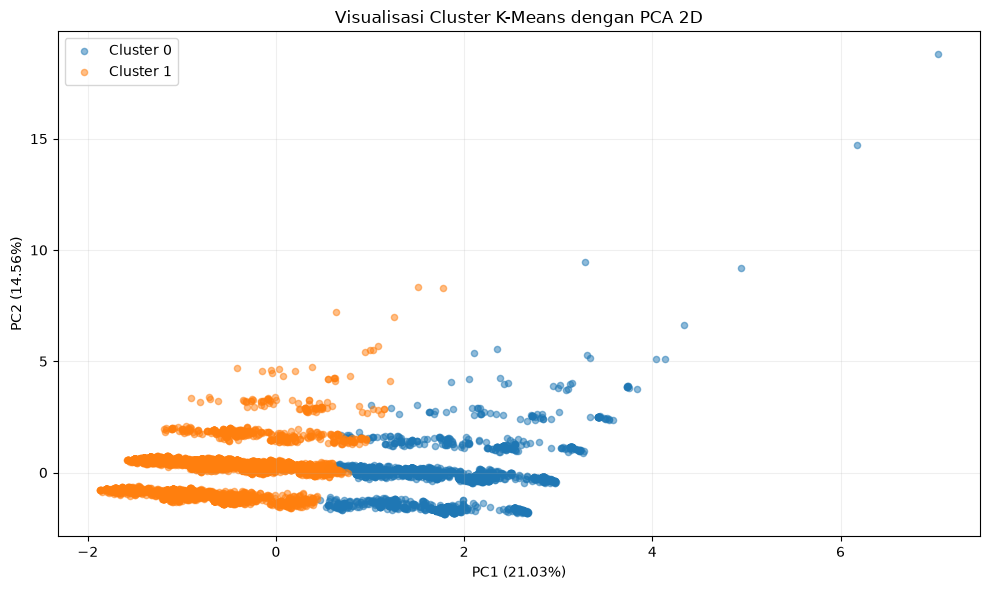

In [54]:
# ============================================
# VISUALISASI PCA 2D - CLUSTER
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster_id in sorted(pca_df["cluster"].unique()):
    cluster_data = pca_df[pca_df["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=20
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

plt.title("Visualisasi Cluster K-Means dengan PCA 2D")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [56]:
# ============================================
# PERBEDAAN FITUR NUMERIK ANTAR CLUSTER
# ============================================

numeric_comparison = (
    df_cluster_result
    .groupby("cluster")[cluster_numeric]
    .mean()
)

# Hitung selisih antar cluster untuk setiap fitur
feature_difference = (
    numeric_comparison.max(axis=0)
    - numeric_comparison.min(axis=0)
)

print("Rata-rata fitur numerik per cluster:")
display(numeric_comparison.round(2))

print("\nSelisih antar cluster:")
display(feature_difference.round(2).sort_values(ascending=False))

Rata-rata fitur numerik per cluster:


,speed_limit,number_of_vehicles
cluster,,
0,58.13,1.92
1,28.53,1.79



Selisih antar cluster:


speed_limit           29.60
number_of_vehicles     0.13
dtype: float64

In [57]:
# ============================================
# TABEL FINAL PROFIL CLUSTER
# ============================================

cluster_final_summary = pd.DataFrame({
    "Jumlah Data": cluster_summary["Jumlah Data"],
    "Rata-rata Speed Limit": cluster_summary["Rata-rata Speed Limit"],
    "Median Speed Limit": cluster_summary["Median Speed Limit"],
    "Rata-rata Jumlah Kendaraan": cluster_summary["Rata-rata Jumlah Kendaraan"],
    "Median Jumlah Kendaraan": cluster_summary["Median Jumlah Kendaraan"],
    "Fatal (%)": cluster_summary["Fatal (%)"],
    "Serious (%)": cluster_summary["Serious (%)"],
    "Slight (%)": cluster_summary["Slight (%)"]
})

cluster_final_summary = cluster_final_summary.round(2)

cluster_final_summary

,Jumlah Data,Rata-rata Speed Limit,Median Speed Limit,Rata-rata Jumlah Kendaraan,Median Jumlah Kendaraan,Fatal (%),Serious (%),Slight (%)
cluster,,,,,,,,
0,2486,58.13,60.0,1.92,2.0,2.98,27.31,69.71
1,7514,28.53,30.0,1.79,2.0,0.87,21.12,78.01


## Interpretasi Profil Cluster

### Cluster 0 — Kelompok dengan Batas Kecepatan Tinggi dan Severity Relatif Lebih Tinggi

Cluster 0 terdiri dari 2.486 data kecelakaan. Kelompok ini memiliki rata-rata batas kecepatan sebesar 58,13, jauh lebih tinggi dibandingkan Cluster 1 yang sebesar 28,53. Rata-rata jumlah kendaraan pada Cluster 0 adalah 1,92.

Berdasarkan distribusi tingkat keparahan, Cluster 0 memiliki proporsi Fatal sebesar 2,98%, Serious sebesar 27,31%, dan Slight sebesar 69,71%. Selain itu, profil kategorikal menunjukkan bahwa Cluster 0 sangat didominasi oleh wilayah rural sebesar 93,00%.

Dengan demikian, Cluster 0 dapat diinterpretasikan sebagai kelompok kecelakaan yang memiliki karakteristik batas kecepatan lebih tinggi dan lebih banyak terjadi pada lingkungan rural, dengan proporsi kecelakaan Fatal dan Serious yang relatif lebih tinggi dibandingkan Cluster 1.

### Cluster 1 — Kelompok Urban dengan Batas Kecepatan Lebih Rendah

Cluster 1 terdiri dari 7.514 data kecelakaan. Kelompok ini memiliki rata-rata batas kecepatan sebesar 28,53 dan rata-rata jumlah kendaraan sebesar 1,79.

Distribusi tingkat keparahannya terdiri dari Fatal sebesar 0,87%, Serious sebesar 21,12%, dan Slight sebesar 78,01%. Profil kategorikal menunjukkan bahwa Cluster 1 didominasi oleh wilayah urban sebesar 87,24%.

Dengan demikian, Cluster 1 dapat diinterpretasikan sebagai kelompok kecelakaan dengan karakteristik batas kecepatan lebih rendah dan dominasi lingkungan urban, dengan proporsi kecelakaan Slight yang lebih tinggi dibandingkan Cluster 0.

## Kesimpulan Hasil Clustering

Berdasarkan proses clustering menggunakan algoritma K-Means, diperoleh dua kelompok kecelakaan lalu lintas dengan karakteristik yang berbeda. Pemilihan jumlah cluster K=2 didukung oleh hasil evaluasi clustering, dengan Silhouette Score sebesar 0,2034.

Cluster 0 terdiri dari 2.486 data dan memiliki karakteristik utama berupa rata-rata batas kecepatan yang lebih tinggi, yaitu 58,13, serta dominasi wilayah rural sebesar 93,00%. Cluster ini juga memiliki proporsi Fatal sebesar 2,98% dan Serious sebesar 27,31%.

Cluster 1 merupakan kelompok terbesar dengan 7.514 data. Cluster ini memiliki rata-rata batas kecepatan lebih rendah, yaitu 28,53, serta didominasi oleh wilayah urban sebesar 87,24%. Proporsi severity pada cluster ini terdiri dari Fatal sebesar 0,87%, Serious sebesar 21,12%, dan Slight sebesar 78,01%.

Perbedaan rata-rata batas kecepatan antara kedua cluster sebesar 29,60, sedangkan perbedaan rata-rata jumlah kendaraan relatif kecil, yaitu 0,13. Hal ini menunjukkan bahwa batas kecepatan merupakan salah satu karakteristik numerik yang paling membedakan kedua kelompok dalam hasil clustering.

Secara keseluruhan, hasil clustering menunjukkan adanya dua pola karakteristik kecelakaan. Cluster 0 merepresentasikan kelompok dengan batas kecepatan relatif tinggi dan dominasi lingkungan rural serta proporsi severity yang relatif lebih tinggi. Sementara itu, Cluster 1 merepresentasikan kelompok dengan batas kecepatan lebih rendah, dominasi lingkungan urban, dan proporsi kecelakaan Slight yang lebih besar.

Hasil clustering ini bersifat deskriptif dan tidak digunakan untuk menyatakan hubungan sebab-akibat antara suatu karakteristik dengan tingkat keparahan kecelakaan.